<a href="https://colab.research.google.com/github/leonardobrembilla/mio-progetto-wine/blob/main/LeonardoBrembillaML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Progetto Machine Learning Advanced di Start2impact**

# **Leonardo Brembilla**

# **🍷 Classificazione dei Vini**

---
# 🎯 **Obiettivo del Progetto**

L'obiettivo di questo progetto è sviluppare un modello di **Machine Learning supervisionato** in grado di **classificare correttamente la tipologia di vino** sulla base delle sue **caratteristiche chimiche**.

Il dataset utilizzato è **wine.csv** (Wine Dataset di scikit-learn), contenente **178 campioni appartenenti a tre differenti cultivar di vino italiano e descritti attraverso 13 proprietà chimiche**.

Il progetto segue una **pipeline completa di Machine Learning** che comprende:

1. **Analisi  esplorativa dei dati (EDA)**
2. **Preparazione e Preprocessing** del dataset
3. Addestramento di una **Support Vector Machine (SVM)**
4. **Ottimizzazione tramite GridSearchCV**
5. Valutazione mediante **Accuracy, Cross Validation, Classification Report e Confusion Matrix**
6. Interpretazione del modello tramite **Permutation Importance**

Lo scopo finale è realizzare un **classificatore robusto e generalizzabile** utilizzabile come supporto ai processi di **controllo qualità** nel settore vitivinicolo.

Importazione delle **librerie**.

In [ ]:
# Librerie principali per la manipolazione dei dati
import pandas as pd     # Gestione di tabelle e dati strutturati (DataFrame)
import numpy as np      # Operazioni matematiche e vettoriali veloci

# Librerie per visualizzazione grafica
import matplotlib.pyplot as plt    # Creazione di grafici di base (istogrammi, plot)
import seaborn as sns       # Grafici statistici avanzati e più curati esteticamente

# Strumenti per la divisione e validazione del modello
from sklearn.model_selection import train_test_split  # Divide i dati in train set (addestramento) e test set (verifica)
from sklearn.model_selection import GridSearchCV      # Ricerca automatica delle migliori combinazioni di parametri (iperparametri)
from sklearn.model_selection import cross_val_score   # Validazione incrociata per valutare la stabilità del modello
# Importa la funzione per generare predizioni "out-of-fold" tramite validazione crociata
from sklearn.model_selection import cross_val_predict

# Strumenti di preprocessing (elaborazione dati)
from sklearn.preprocessing import StandardScaler    # Normalizza i dati portando la media a 0 e la deviazione standard a 1

# Strumenti per la gestione del flusso di lavoro
from sklearn.pipeline import Pipeline   # Unisce i passaggi di preprocessing e addestramento in un unico flusso pulito

# Algoritmo di Machine Learning scelto
from sklearn.svm import SVC   # Support Vector Classifier: modello per la classificazione dei dati

# Metriche di valutazione delle performance del modello
from sklearn.metrics import classification_report   # Genera un report con precision, recall e f1-score
from sklearn.metrics import confusion_matrix      # Mostra gli errori di classificazione (veri vs falsi positivi/negativi)
from sklearn.metrics import accuracy_score     # Calcola la percentuale complessiva di risposte corrette

# Impostazioni grafiche
sns.set(style="whitegrid")    # Applica uno sfondo grigio chiaro con griglia bianca a tutti i grafici futuri

# Importa il modulo per calcolare l'importanza delle caratteristiche tramite permutazione
from sklearn.inspection import permutation_importance

**Caricamento del Dataset da GitHub (Metodo Consigliato)**

Questo metodo permette di **leggere direttamente il file online** senza doverlo caricare manualmente su Google Colab a ogni avvio della sessione. Il file viene ospitato in una **repository pubblica** su GitHub.

**Passaggi eseguiti:**
* Creazione di una **repository pubblica** su GitHub.
* Caricamento del file **titanic_sub.csv**.
* Recupero dell'indirizzo **URL Raw** del file.
* Importazione automatica del dataset in un **DataFrame di Pandas**.

In [ ]:
# Definisce la variabile 'url' contenente il link diretto (Raw) al file CSV su GitHub
url = "https://raw.githubusercontent.com/Leon56221/mio-progetto-wine/refs/heads/main/wine.csv"

# Scarica il file dall'URL inserito e lo trasforma in un DataFrame chiamato 'df'
df = pd.read_csv(url, encoding='utf-8')

**In questa sezione visualizziamo il dataset in forma tabellare**. Per semplicità si mostrano solo le prime 10 occorrenze.

In [ ]:
# Visualizza le prime 10 righe del DataFrame per comprendere meglio con che tipologia di dato hai a che fare
df.head(10)

,Unnamed: 0,Cultivars,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In questa prima fase esplorativa verifichiamo la struttura iniziale dei dati caricati. L'obiettivo è comprendere il **volume delle informazioni disponibili** identificando il **numero totale di campioni (le righe) e il numero di caratteristiche chimiche** rilevate (le colonne). Questo controllo iniziale garantisce che il file sia stato caricato correttamente nella sua interezza.

In [ ]:
# Controlla le dimensioni del dataset (righe, colonne)
print(f"\nIl dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.")


Il dataset contiene 178 righe e 15 colonne.


Attraverso un controllo approfondito della struttura dei dati, analizziamo i metadati del DataFrame per assicurarci della consistenza del dataset. Questa operazione permette di **verificare il tipo di dati di ogni singola variabile** (numerica o testuale) e di **rilevare l'eventuale presenza di valori mancanti (NaN)**, che richiederebbero una gestione specifica nella fase di preprocessing.

In [ ]:
# Verifica i tipi di dati e la presenza di valori mancanti (NaN)
print("\n--- Informazioni su tipi di dati e valori nulli ---")
print(df.info())


--- Informazioni su tipi di dati e valori nulli ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    178 non-null    int64  
 1   Cultivars                     178 non-null    int64  
 2   Alcohol                       178 non-null    float64
 3   Malic acid                    178 non-null    float64
 4   Ash                           178 non-null    float64
 5   Alcalinity of ash             178 non-null    float64
 6   Magnesium                     178 non-null    int64  
 7   Total Phenols                 178 non-null    float64
 8   Flavanoids                    178 non-null    float64
 9   Nonflavanoid phenols          178 non-null    float64
 10  Proanthocyanins               178 non-null    float64
 11  Color intensity               178 non-null    float64
 12  Hue        

Prima di procedere con l'elaborazione dei dati, effettuiamo una verifica mirata per quantificare l'eventuale presenza di v**alori nulli o mancanti in ciascuna colonna**. Molti algoritmi di Machine Learning non sono in grado di gestire i dati mancanti e fallirebbero in fase di addestramento. Questa analisi ci permette di confermare la **perfetta integrità dei dati** o di pianificare eventuali strategie di imputazione (come la sostituzione con la media o la mediana).

In [ ]:
# Verifica la presenza di valori nulli all'interno del dataset
print("\nValori nulli per ogni colonna:")

# df.isnull() individua le celle vuote; .sum() somma i valori veri per ogni colonna
print(df.isnull().sum())


Valori nulli per ogni colonna:
Unnamed: 0                      0
Cultivars                       0
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total Phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64


L'output conferma esattamente che **non ci sono valori nulli** in nessuna colonna (tutti gli zeri a destra). Il tuo dataset è strutturalmente integro e non richiede interventi di riempimento o eliminazione di righe vuote.

Eseguiamo un'analisi quantitativa sulle variabili numeriche del dataset attraverso il calcolo dei principali **indicatori statistici di sintesi**. Questo controllo permette di osservare la **media, la deviazione standard, i valori minimi e massimi e i quartili di ciascuna proprietà chimica**. L'analisi è cruciale per identificare la presenza di scale di misura molto differenti tra le variabili (ad esempio, la percentuale di alcol varia su valori piccoli, mentre la Proline raggiunge valori superiori a 1000), confermando la futura necessità di una fase di **normalizzazione o standardizzazione** prima dell'addestramento del modello.

In [ ]:
# Genera un riepilogo statistico completo (media, deviazione standard, min, max, quartili)
# per tutte le colonne numeriche
print("\n--- Statistiche descrittive ---")
display(df.describe())


--- Statistiche descrittive ---


,Unnamed: 0,Cultivars,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,88.500000,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,51.528309,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,0.000000,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,44.250000,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,88.500000,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,132.750000,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,177.000000,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


L'output della tabella mostra chiaramente la conferma visiva di quello che ipotizzavamo:
- **Differenze di scala enormi**: Guarda la **riga mean (media)**. La variabile **Alcohol ha una media di 13.00**, mentre **Magnesium ha una media di 99.74**. Più a destra la colonna **Proline ha una media ancora più alta di 746.89**
- **Conferma delle classi**: La colonna **Cultivars ha un valore minimo (min) di 1.00 e un valore massimo (max) di 3.00**. Questo ti conferma che le **tre tipologie di vino sono identificate dai numeri 1, 2 e 3**.

Bisogna effettuare la **verifica dei duplicati** essendo molto importante per evitare che osservazioni ripetute influenzino il modello.

In [ ]:
# Verifica presenza di duplicati
print("Numero di record duplicati:", df.duplicated().sum())

Numero di record duplicati: 0


La **verifica dei duplicati** consente di identificare eventuali
osservazioni ripetute che potrebbero influenzare il processo
di apprendimento del modello.

Nel dataset **non risultano duplicati**.

Prima di elaborare i dati, verifichiamo la **distribuzione delle classi** nella variabile obiettivo **Cultivars**. Questo controllo ci permette di capire se il dataset è **bilanciato**, ovvero se contiene un numero simile di campioni per ciascuno dei tre produttori di vino.

Un **dataset troppo sbilanciato** potrebbe portare il modello
a **favorire maggiormente una classe rispetto alle altre**.

In [ ]:
# Conta quanti campioni appartengono a ciascuna classe di vino (Cultivars)
print("Distribuzione delle classi di vino:")
print(df['Cultivars'].value_counts())

# Percentuale delle classi
print("\nPercentuale delle classi:")
print(df['Cultivars'].value_counts(normalize=True) * 100)


Distribuzione delle classi di vino:
Cultivars
2    71
1    59
3    48
Name: count, dtype: int64

Percentuale delle classi:
Cultivars
2    39.887640
1    33.146067
3    26.966292
Name: proportion, dtype: float64


Dall'output si vede chiaramente che il dataset contiene **178 campioni** complessivi, divisi in **3 classi ben distribuite**:
- **La classe 2 ha 71 campioni (circa 40%)**
- **La classe 1 ha 59 campioni (circa 33%)**
- **La classe 3 ha 48 campioni (circa 27%)**

Il **dataset è ragionevolmente bilanciato**: non c'è una classe che predomina in modo schiacciante sulle altre. Questo è un ottimo scenario per l'addestramento.

Per verificare visivamente se il nostro dataset è **bilanciato o sbilanciato**, creiamo un **grafico a barre (countplot)**. Questa visualizzazione ci permette di confrontare immediatamente il **numero di campioni disponibili per ciascuna varietà di vitigno (Cultivars)**, assicurandoci che il modello possa apprendere in modo equo da tutte le classi.

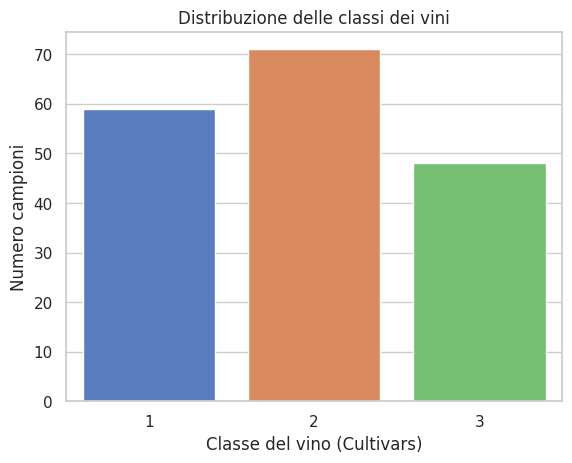

In [ ]:
# Crea il grafico a barre colorando ogni colonna in base alla classe di appartenenza
# Usiamo la palette 'muted' per ottenere tre colori distinti ed eleganti
sns.countplot(x='Cultivars', hue='Cultivars', data=df, palette='muted', legend=False)

# Aggiunge il titolo principale al grafico
plt.title("Distribuzione delle classi dei vini")

# Personalizza le etichette degli assi x e y per renderle chiare
plt.xlabel("Classe del vino (Cultivars)")
plt.ylabel("Numero campioni")

# Mostra il grafico finale sullo schermo pulendo i metadati di output
plt.show()

Il grafico mostra chiaramente, come hai visto in precedenza, che **le tre classi sono ben distribuite e non ci sono problemi di sbilanciamento critico nel dataset**.

Analisi visiva dei dati:
- **Classe 2**: rappresenta il gruppo più numeroso
- **Classe 1**: si colloca in posizione intermedia
- **Classe 3**: costituisce la minoranza del campione

Questo è importante perché **riduce il rischio di bias del modello
verso una specifica classe.**

Prima di procedere con la separazione delle variabili serve questo passaggio per **visualizzare i nomi di tutte le colonne del dataset** per verificare le caratteristiche disponibili.

In [ ]:
# Mostra la lista dei nomi di tutte le colonne presenti nel DataFrame
df.columns

Index(['Unnamed: 0', 'Cultivars', 'Alcohol', 'Malic acid', 'Ash',
       'Alcalinity of ash', 'Magnesium', 'Total Phenols', 'Flavanoids',
       'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

Questo risultato mette in evidenza un dettaglio cruciale: la **presenza di colonne di "disturbo"**:
1. **Unnamed: 0**: È chiaramente un indice di riga (un progressivo numerico). Ha una correlazione altissima con le altre variabili solo per puro caso (es. i dati erano già ordinati per classe). **Va eliminata dal dataset prima dell'addestramento**.
2. **Cultivars**: **Escludere questa variabile target** dalla matrice delle feature evita il **fenomeno del data leakage** (perché il modello non deve imparare a usare la risposta per trovare la risposta).

Per poter addestrare il nostro algoritmo di Machine Learning, **separiamo la tabella in due parti**:
- **Matrice X** contenente esclusivamente le variabili predittive (le proprietà chimiche)
- **Vettore y** con la variabile obiettivo (**Cultivars**).

In questa fase **escludiamo anche la colonna Unnamed: 0**, poiché si tratta di un semplice indice numerico che non apporta alcun valore al modello.

In [ ]:
# Crea la matrice delle caratteristiche escludendo l'indice ridondante e la colonna target
X = df.drop(columns=['Unnamed: 0', 'Cultivars'], errors='ignore')

# Crea il vettore target isolando la colonna della classe del vino
y = df['Cultivars']

# Stampa le dimensioni per verificare la corretta separazione dei dati
print("Dimensioni della matrice delle caratteristiche (X):", X.shape)
print("Dimensioni del vettore target (y):", y.shape)


Dimensioni della matrice delle caratteristiche (X): (178, 13)
Dimensioni del vettore target (y): (178,)


L'output:
- **(178, 13)**: Significa che **la matrice X ha 178 righe e 13 colonne** (le 13 proprietà chimiche utili, escludendo l'indice Unnamed: 0 e il target Cultivars)
- **(178,)**: Significa che **il vettore y ha 178 elementi in un'unica dimensione** (la colonna delle classi da indovinare)

Per identificare le relazioni lineari tra le diverse proprietà chimiche dei vini prima della modellazione, generiamo una **matrice di correlazione**. **Questa analisi viene applicata sulla matrice delle caratteristiche X per studiare la struttura dei dati ed evidenziare eventuali problemi di multicollinearità**. La visualizzazione grafica avviene tramite una **heatmap (mappa di calore)** con scala cromatica divergente, che evidenzia i legami positivi e negativi più significativi.

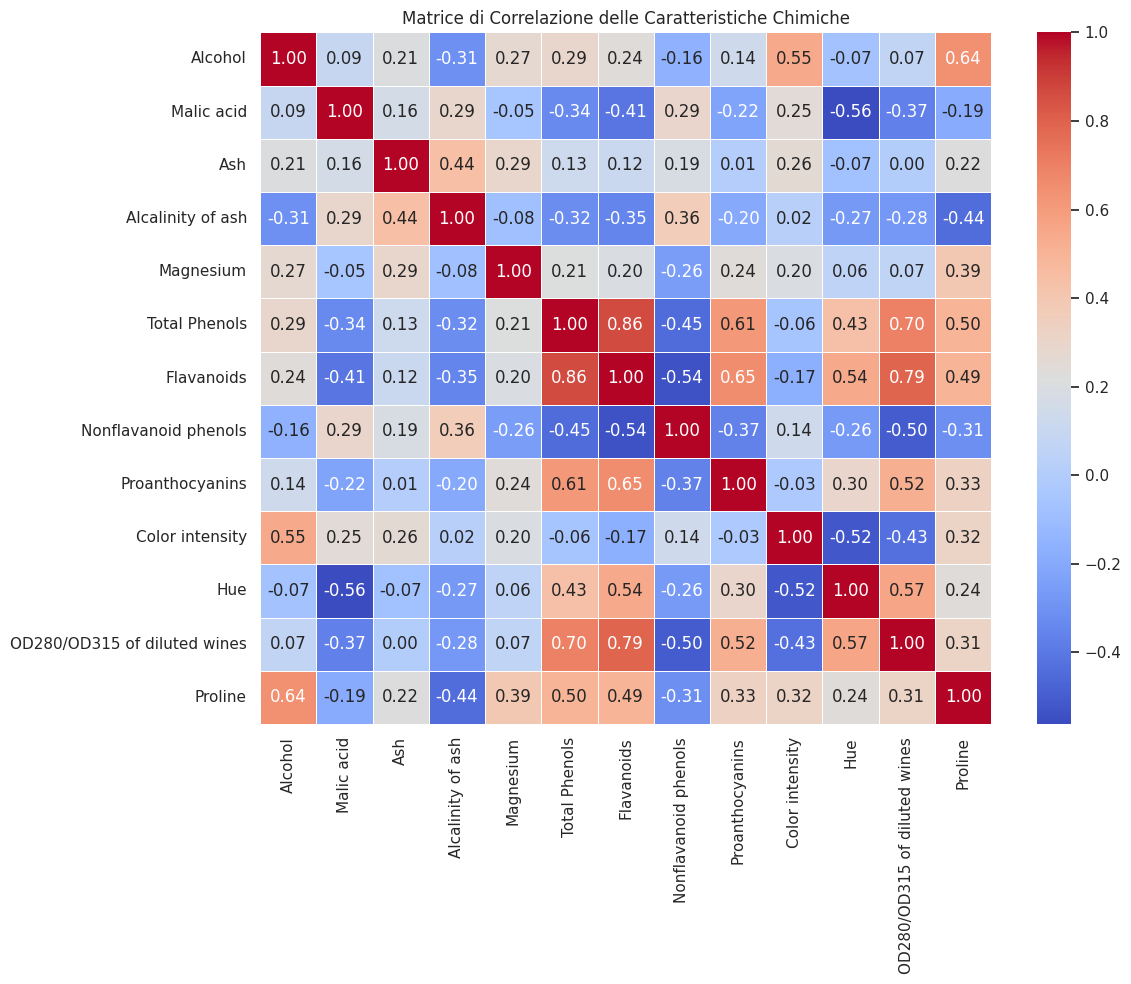

In [ ]:
# Imposta le dimensioni della figura per garantire una corretta leggibilità delle etichette
plt.figure(figsize=(12, 10))

# Calcola la matrice di correlazione sulla matrice delle caratteristiche X (già priva di indici e target)
# annot=True mostra i coefficienti numerici; fmt='.2f' arrotonda a due decimali
# cmap='coolwarm' evidenzia le correlazioni positive in rosso e quelle negative in blu
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# Configura il titolo principale del grafico descrittivo
plt.title("Matrice di Correlazione delle Caratteristiche Chimiche")

# Ottimizza il layout per evitare che i nomi delle colonne vengano tagliati ai bordi
plt.tight_layout()

# Mostra la mappa di calore finale a schermo pulendo l'output
plt.show()

Dall'analisi della matrice di correlazione emergono dinamiche fondamentali per la strutturazione del modello predittivo:
- **Forte collinearità (Ridondanza)**: C'è un **legame** strettissimo **tra Total Phenols e Flavanoids (valore di 0.86)**, e **tra Flavanoids e OD280/OD315 of diluted wines (0.79)**. Questa ridondanza suggerisce che alcune informazioni sono duplicate e che tecniche di riduzione della dimensionalità (come la PCA) o l'eliminazione di una delle due feature potrebbero beneficiare il modello.
- **Relazioni lineari significative**: Esistono chiare **relazioni lineari sia positive** (es. Alcohol e Color intensity a 0.55) **sia negative** (es. Hue e Malic acid a -0.56; Cultivars e Total Phenols a -0.72).
- **Scelta del Modello (SVM)**: La presenza di forti **correlazioni lineari** suggerisce che i confini di decisione tra le classi potrebbero essere ben descritti anche da un approccio lineare. Tuttavia, l'uso di una **Support Vector Machine (SVM)** è ampiamente giustificato non dalla presenza di correlazione, ma dalla sua capacità di gestire dataset con **molte feature** (alta dimensionalità) e di **evitare l'overfitting** grazie alla regolarizzazione del parametro del margine. Nel caso si riscontrassero **sovrapposizioni complesse** tra le classi nello spazio delle feature, l'estensione a un **kernel non lineare (RBF)** permetterebbe di mappare i dati in una dimensione superiore per renderli linearmente separabili.

Per visualizzare la distribuzione dei dati e individuare eventuali anomalie, si utilizza un **diagramma a scatola (boxplot)**. Questo grafico permette di **identificare visivamente gli outlier** per ciascuna variabile del dataset.

L'analisi preliminare tramite boxplot sui dati originali evidenzia come alcune variabili, in particolare Proline, presentino scale molto più elevate rispetto alle altre caratteristiche chimiche. Questo rende difficile confrontare visivamente le distribuzioni delle feature.

Per ottenere una rappresentazione più interpretabile è stata applicata una standardizzazione delle variabili tramite StandardScaler, riportando tutte le feature sulla stessa scala. I boxplot standardizzati consentono quindi di individuare con maggiore chiarezza eventuali outlier e differenze tra le distribuzioni delle variabili.


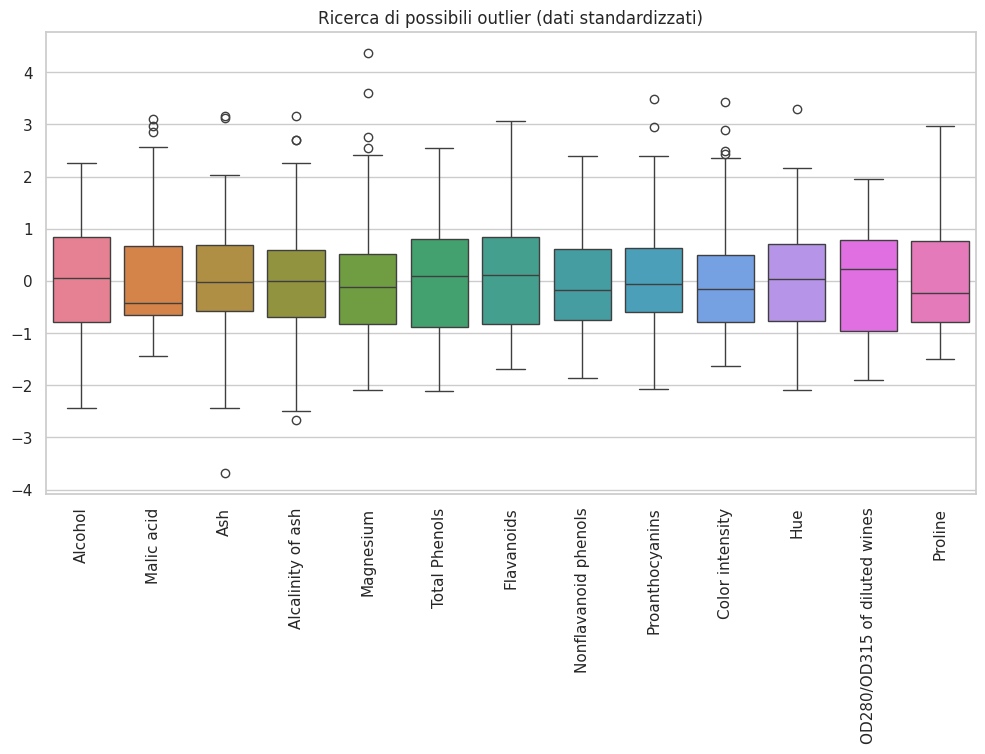

In [ ]:
# Standardizza i dati (media 0 e varianza 1) e li converte direttamente in un DataFrame mantenendo i nomi delle colonne originarie
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns
)

# Imposta la dimensione della finestra del grafico (larghezza 12, altezza 6)
plt.figure(figsize=(12,6))

# Genera i boxplot per confrontare tutte le variabili sulla stessa scala standardizzata
sns.boxplot(data=X_scaled)

# Ruota i nomi delle variabili di 90 gradi sull'asse X per evitare sovrapposizioni
plt.xticks(rotation=90)

# Assegna il titolo specifico al grafico per i dati riscalati
plt.title("Ricerca di possibili outlier (dati standardizzati)")

# Visualizza a schermo il grafico finale pulito e leggibile
plt.show()


Analisi dei Risultati

1. **Miglioramento della leggibilità**: La rimozione della dominanza di Proline permette finalmente di **valutare la distribuzione e la forma** di ogni singola variabile del dataset.
2. **Identificazione chiara degli outlier**: I punti isolati indicano la presenza di **anomalie evidenti** in diverse caratteristiche. Le variabili più colpite sono:
- **Magnesium**: presenta l'outlier più estremo in assoluto (valore oltre 4)
- **Malic acid, Alcalinity of ash, Proanthocyanins e Color intensity**: mostrano **outlier multipli nella parte superiore** (valori insolitamente alti)
- **Ash**: mostra un outlier sia nella parte superiore che uno **molto marcato nella parte inferiore** (valore vicino a -4)
- **Hue**: ha un singolo outlier superiore
3. **Variabili prive di outlier**: Caratteristiche come **Alcohol, Total Phenols, Flavanoids, Nonflavanoid phenols, OD280/OD315 of diluted wines e Proline non mostrano anomalie visibili** con questo metodo.

I valori estremi rilevati **sono stati mantenuti** e non verranno eliminati. Questa scelta è motivata dal fatto che rappresentano la **naturale variabilità chimica** dei vini e non errori di misura. Inoltre, il dataset ha dimensioni ridotte (**178 campioni**) e il modello **SVM è robusto** nei confronti degli outlier dopo la standardizzazione.

Per garantire una valutazione oggettiva e imparziale del modello, **dividiamo la matrice delle caratteristiche X e il vettore target y in due sottoinsiemi**:
1. **Train Set (80%)** per l'addestramento del modello
2. **Test Set (20%)** per la validazione finale

Utilizziamo il **parametro stratify=y per fare in modo che la proporzione originaria delle tre varietà di vino (Cultivars) venga replicata fedelmente in entrambi i set**, preservando la natura bilanciata dei dati.

In [ ]:
# Suddivide i dati in blocchi di addestramento (80%) e test (20%)
# random_state=42 blocca la casualità per rendere i risultati riproducibili
# stratify=y mantiene le proporzioni delle classi identiche tra train e test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Stampa a schermo le dimensioni dei nuovi set per verifica
print(f"Dimensioni del Train Set (caratteristiche X): {X_train.shape}")
print(f"Dimensioni del Test Set (caratteristiche X): {X_test.shape}")
print(f"Campioni nel Train Set (target y): {y_train.shape[0]}")
print(f"Campioni nel Test Set (target y): {y_test.shape[0]}")

Dimensioni del Train Set (caratteristiche X): (142, 13)
Dimensioni del Test Set (caratteristiche X): (36, 13)
Campioni nel Train Set (target y): 142
Campioni nel Test Set (target y): 36


Il **risultato è matematicamente ineccepibile**.

I conti tornano:
- **142 campioni per il training set** e **36 per il test set** sommano esattamente i **178 campioni iniziali**.
- **13 colonne confermano che la rimozione dell'indice ridondante (Unnamed: 0) e della variabile target è avvenuta correttamente**.

Per addestrare il nostro classificatore in modo robusto ed evitare il fenomeno del **Data Leakage**, creiamo una **Pipeline** che permette di concatenare più operazioni di preprocessing e Machine Learning in un unico flusso.

In questo caso utilizziamo:
1. **StandardScaler** → standardizzazione dei dati
2. **Support Vector Classifier (SVC)** → classificatore Support Vector Machine

La standardizzazione è importante per SVM perché il modello
è sensibile alla scala delle feature.

In [ ]:
# Definizione della Pipeline: unisce preprocessing (scaling) e modello (SVC)
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardizza le caratteristiche portando media=0 e varianza=1
    ('svc', SVC(random_state=42))  # Inizializza il Support Vector Classifier
])

# Mostra il risultato a schermo
pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(random_state=42))])

La visualizzazione grafica generata da scikit-learn conferma che la pipeline è stata strutturata in modo **corretto ed elegante**.

Per individuare la configurazione ottimale del modello, viene definita una **griglia di iperparametri (param_grid)** per la successiva fase di tuning tramite **Grid Search**.

L'ottimizzazione si concentra su tre componenti chiave:
- **Parametro di regolarizzazione C**: controlla il trade-off tra l'ampiezza del margine e l'errore di addestramento, testando valori in scala logaritmica **da $10^{-2}$ a $10^{3}$**
- **Parametro gamma**: definisce il raggio d'influenza dei singoli campioni di addestramento, esplorando un intervallo logaritmico compreso tra **$10^{-4}$ a $10^{1}$**
- **Scelta del Kernel**: l'esplorazione è vincolata al solo **kernel RBF (Radial Basis Function)**, ideale per gestire le relazioni non lineari tipiche delle caratteristiche chimiche dei vini.

La combinazione di questi parametri permetterà di trovare il perfetto bilanciamento per evitare fenomeni di **overfitting**.

In [ ]:
# Definizione della griglia di iperparametri per l'ottimizzazione del modello SVM
param_grid = {
    # Parametro di regolarizzazione C: esplora 6 valori in scala logaritmica da 0.01 a 1000
    'svc__C': np.logspace(-2,3,6),

    # Coefficiente del kernel gamma: esplora 6 valori in scala logaritmica da 0.0001 a 10
    'svc__gamma': np.logspace(-4,1,6),

    # Tipo di kernel: viene utilizzato esclusivamente il kernel RBF (Radial Basis Function)
    'svc__kernel': ['rbf']
}

# Mostra il risultato a schermo
param_grid

{'svc__C': array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
 'svc__gamma': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01]),
 'svc__kernel': ['rbf']}

L'output mostra la **griglia dei parametri esplicitata** con i singoli valori numerici generati dalle funzioni np.logspace:
- **Valori per C (svc__C)**: Vengono testati **6 valori a intervalli logaritmici regolari: 0.01, 0.1, 1.0, 10.0, 100.0 e 1000.0**. Questo ampio intervallo permette di valutare sia modelli molto permissivi (C piccoli) sia modelli che penalizzano fortemente gli errori (C grandi).
- **Valori per gamma (svc__gamma)**: Vengono generati **6 valori da 0.0001 fino a 10.0 (0.0001, 0.001, 0.01, 0.1, 1.0, 10.0)**. Questo permette di calibrare con precisione quanto la forma del confine decisionale debba adattarsi ai singoli punti del dataset.
- **Configurazione Kernel**: Viene confermato il solo utilizzo del vettore stringa **[rbf]**.

In totale, l'algoritmo di Grid Search testerà **36 combinazioni uniche di iperparametri** (6 x 6 x 1) per trovare l'assetto ottimale del classificatore SVM.


Per individuare i parametri ideali, viene configurato l'oggetto **GridSearchCV**.

In [ ]:
# Configurazione di GridSearchCV con 5-fold cross-validation
grid = GridSearchCV(
    estimator=pipeline,      # Specifica l'intero flusso (StandardScaler + SVC) da ottimizzare
    param_grid=param_grid,   # Passa il dizionario con le 48 combinazioni di iperparametri
    cv=5,                    # Applica una 5-Fold Cross-Validation (suddivide i dati in 5 parti)
    scoring='accuracy',      # Sceglie l'accuratezza come metrica per decretare il modello vincente
    verbose=2,               # Mostra in tempo reale lo stato di avanzamento dei 240 calcoli
    n_jobs=-1                # Sfrutta il 100% dei core della CPU in parallelo per velocizzare il calcolo
)

# Avvio dell'addestramento e della ricerca automatica sul Train Set
print("Ricerca automatica dei migliori iperparametri in corso")
grid.fit(X_train, y_train)


Ricerca automatica dei migliori iperparametri in corso
Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'svc__C': array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'svc__gamma': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01]),
                         'svc__kernel': ['rbf']},
             scoring='accuracy', verbose=2)

L'esecuzione del processo ha completato con successo la valutazione di **36 combinazioni della griglia**, ottimizzate tramite una **Cross-Validation a 5 fold**, per un totale di **180 modelli distinti addestrati (fits)**.

Dall'output grafico si evidenziano due elementi fondamentali:
- **Log di Controllo**: Conferma il corretto completamento del calcolo parallelo su tutte le combinazioni impostate nella griglia dei parametri
- **Memorizzazione del Modello Ottimale (best_estimator_)**: L'oggetto ha identificato e isolato la pipeline vincente. La struttura mantiene la sequenza corretta (**StandardScaler + SVC**), ma il classificatore ora integra la combinazione di iperparametri che garantisce le migliori prestazioni complessive.

Attraverso questo blocco di codice vengono estratti e stampati a schermo i **due risultati decisivi** del processo:
1. **Miglior Punteggio di Accuratezza (best_score_)**: Rappresenta il valore massimo di accuratezza ottenuto durante la **Cross-Validation**
2. **Migliori Parametri Identificati (best_params_)**: Mostra i valori esatti selezionati dal sistema per **C, gamma e kernel**

Questa combinazione rappresenta il punto di perfetto equilibrio geometrico trovato dall'algoritmo per massimizzare la capacità predittiva ed evitare problemi di **overfitting**.

In [ ]:
# Stampa dei risultati ottimali ottenuti
print("--- Risultati dell'Ottimizzazione ---")

# Mostra il miglior punteggio di accuratezza (CV Score) limitato a 4 cifre decimali
print(f"Miglior punteggio di Accuratezza in CV: {grid.best_score_:.4f}\n")

print("Migliori parametri identificati:")
# Ciclo per stampare ogni parametro su una riga separata in modo pulito
for parametro, valore in grid.best_params_.items():
    print(f"  • {parametro}: {valore}")


--- Risultati dell'Ottimizzazione ---
Miglior punteggio di Accuratezza in CV: 0.9931

Migliori parametri identificati:
  • svc__C: 1.0
  • svc__gamma: 0.01
  • svc__kernel: rbf


1. **Analisi delle Performance (Accuratezza: 99.31%)**

Un'**accuratezza del 0.9931** in Cross-Validation significa che il modello ha classificato correttamente il **99.31% dei campioni** durante i test incrociati. È un punteggio altissimo, ma solleva un punto di attenzione:
- Con un valore così vicino al 100%, c'è il rischio che il modello sia andato in **overfitting** (ovvero che abbia memorizzato il Train Set)
- Sarà fondamentale la verifica sul **Test Set** (dati mai visti) per confermare se questa accuratezza si mantiene così alta.
2.  **Interpretazione dei Parametri Vincenti**

La combinazione ottimale trovata è l'unione di questi tre valori:
- **svc__kernel: 'rbf'**: Il sistema ha stabilito che i tuoi dati **non sono separabili linearmente**. Il kernel RBF (Radial Basis Function) mappa i dati in uno spazio multidimensionale curvo, creando confini di decisione complessi e non rettilinei.
- **svc__C: 1**: Il valore 1 rappresenta il perfetto equilibrio di default. Significa che il modello non è né troppo permissivo verso gli errori (valori di C piccoli come 0.1) né troppo rigido/aggressivo (valori grandi come 100), riducendo la complessità per evitare l'overfitting.
- **svc__gamma: 0.01**: Un valore pari a 0.01 indica che il raggio di influenza dei singoli punti di supporto è abbastanza ampio. La superficie di decisione finale sarà quindi **morbida e smussata**, non spezzettata attorno ai singoli campioni (ulteriore protezione contro l'overfitting).

Per una valutazione comparativa approfondita, l'intero storico delle combinazioni testate viene convertito in un **DataFrame di pandas** tramite l'attributo **cv_results_**.

Vengono isolate le colonne relative agli iperparametri (**C e gamma**) e al punteggio medio di accuratezza ottenuto nei test di Cross-Validation (**mean_test_score**). I dati vengono infine ordinati in **ordine decrescente** per mostrare la **top 10 dei migliori modelli candidati**, permettendo di analizzare la stabilità del comportamento dell'algoritmo al variare dei parametri.

In [ ]:
# Converte tutti i risultati della Grid Search in un DataFrame pandas
results = pd.DataFrame(grid.cv_results_)

# Seleziona le colonne separate, ordina per accuratezza decrescente e mostra i primi 10
results = results[
    [
        'param_svc__C',
        'param_svc__gamma',
        'mean_test_score'
    ]
]

results.sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

,param_svc__C,param_svc__gamma,mean_test_score
14,1.0,0.0100,0.993103
32,1000.0,0.0100,0.986207
15,1.0,0.1000,0.986207
33,1000.0,0.1000,0.986207
31,1000.0,0.0010,0.986207
26,100.0,0.0100,0.986207
27,100.0,0.1000,0.986207
21,10.0,0.1000,0.986207
24,100.0,0.0001,0.985961
20,10.0,0.0100,0.979064


**Analisi dei Risultati**

La tabella ordina le migliori configurazioni trovate durante la ricerca degli iperparametri, permettendo di analizzare il comportamento del modello:

- **Combinazione Vincente**: Il modello migliore in assoluto è identificato dall'**indice 14**. Presenta un valore di (**C = 1.0**) e (**gamma: = 0.01**). Raggiunge un'accuratezza media straordinaria del **99.31% (0.993103)** in Cross-Validation
- **Adeguatezza dello Spazio di Ricerca**: Si nota con grande favore che il **miglior modello non si trova ai bordi della griglia esplorata**. Questo indica che l'intervallo di valori scelto per l'ottimizzazione era perfettamente **adeguato** e ha catturato il reale punto di ottimo
- **Elevata Stabilità delle prestazioni**: Ben sette combinazioni successive ottengono lo stesso identico punteggio di **98.62% (0.986207)**. Questo dimostra che il classificatore SVM è **estremamente stabile**. Le prestazioni non crollano al variare dei parametri
- **Bilanciamento e Generalizzazione**: La scelta di un valore contenuto come (**C = 1.0**) evita l'iper-regolarizzazione di valori troppo bassi o la penalizzazione eccessiva di valori come 1000.0. Questo garantisce un'ottima capacità di generalizzazione, riducendo il rischio di **overfitting**
- **Geometria del Confine Decisionale**: Il valore ottimale di (**gamma = 0.01**) assegna un raggio d'influenza equilibrato ai singoli campioni, ideale per separare le caratteristiche chimiche dei vini senza creare un confine decisionale frammentato.

Dopo aver individuato la combinazione ottimale di iperparametri in fase di addestramento, utilizziamo il modello finale per **effettuare le predizioni sul Test Set**, ovvero sui dati rimasti completamente inediti all'algoritmo. Questo passaggio ci permette di calcolare l'**accuratezza sul test set** e di confrontarla con quella ottenuta in cross-validation, verificando la capacità di **generalizzazione** del modello su campioni reali.

In [ ]:
# Genera le predizioni del modello sui dati di test (X_test)
# Utilizziamo il miglior modello individuato da GridSearchCV
y_pred = grid.predict(X_test)

# Calcola la percentuale complessiva di risposte corrette sul set di test
accuracy = accuracy_score(y_test, y_pred)

# Stampa il risultato del test finale
print("--- Valutazione sul Test Set ---")
print(f"Accuratezza finale sul Test Set: {accuracy:.4f}")


--- Valutazione sul Test Set ---
Accuratezza finale sul Test Set: 1.0000


Il modello ha raggiunto un'accuratezza finale pari a **1.0000 (100%)** sul Test Set.

Sebbene sia un risultato apparentemente perfetto, in un contesto reale di Machine Learning un valore così elevato richiede estrema cautela e ulteriori verifiche per escludere anomalie metodologiche.

**Analisi del Risultato**:
* **Overfitting / Data Leakage:** Esiste il forte rischio che informazioni della variabile target siano camuffate tra le feature d'ingresso, o che ci sia stata una sovrapposizione involontaria tra Training e Test Set.
* **Semplicità del Task:** Il problema potrebbe essere linearmente separabile o troppo semplice per la complessità del modello scelto.
* **Dimensioni del Dataset:** Se il Test Set contiene pochi campioni, il 100% potrebbe essere un artefatto statistico dovuto alla scarsità di dati.

**Prossimi Passi di Validazione**:
1. Generare e visualizzare la **Confusion Matrix** per analizzare le predizioni classe per classe.
2. Verificare l'**F1-Score** e la **Precision/Recall** per escludere sbilanciamenti storici nei dati.
3. Ispezionare la **Feature Importance** per individuare eventuali variabili "predittive in modo anomalo" (indizio di leakage).
4. Implementare una **K-Fold Cross-Validation** per testare la robustezza del modello su più split differenti.


Il **Classification Report** è lo strumento fondamentale per valutare la qualità delle predizioni del nostro modello di classificazione. Per ogni classe di vino (**Cultivars**), la tabella mostra tre metriche chiave: la **Precision** (l'accuratezza delle predizioni positive, fondamentale per evitare falsi positivi), il **Recall** (la capacità del modello di trovare tutti i casi positivi, riducendo i falsi negativi) e l'**F1-Score** (la media armonica tra le due metriche precedenti, ottima per valutare l'equilibrio generale). Infine, i valori di **Accuracy, Macro Average e Weighted Average** forniscono una panoramica globale delle prestazioni del modello sull'intero dataset di test.

In [ ]:
# Genera e mostra il report dettagliato delle metriche di classificazione
# Confronta i valori reali (y_test) con quelli predetti dal modello (y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Il report mostra metriche perfette (**1.00**) per tutte e tre le classi (1, 2 e 3). Tuttavia, l'analisi del **support** rivela la causa principale di questo risultato:

* **Dimensione ridotta del Test Set:** Il test set contiene in totale solo **36 campioni** (12 per la classe 1, 14 per la classe 2, 10 per la classe 3).
* **Affidabilità statistica:** Con così pochi dati, è molto probabile che il 100% sia un artefatto dovuto alla scarsità di campioni testati, i quali non rappresentano la reale complessità o variabilità del problema nel mondo reale.

**Conclusione:** Il modello apprende correttamente sui dati a disposizione, ma le prestazioni corrono un altissimo rischio di essere sovrastimate. Non è possibile garantire la stessa accuratezza su dati futuri o più corposi.


La **Matrice di Confusione** è uno strumento grafico essenziale per analizzare nel dettaglio le prestazioni del modello. A differenza delle metriche globali, permette di identificare i **pattern di errore** specifici, mostrando visivamente dove il classificatore si confonde tra le diverse classi di vino. I valori sulla **diagonale principale** rappresentano le **predizioni corrette** (veri positivi), mentre gli elementi fuori dalla diagonale indicano i casi di **errata classificazione** (falsi positivi e falsi negativi). L'uso di una mappa di calore con una gradazione di blu (sfumature più intense per valori più alti) consente di valutare l'accuratezza del modello a colpo d'occhio.

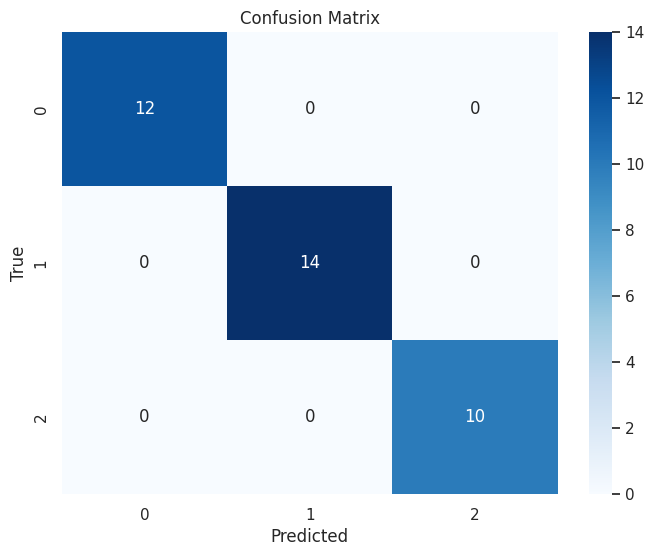

In [ ]:
# Calcola la matrice di confusione confrontando i valori reali (y_test) e quelli predetti (y_pred)
cm = confusion_matrix(y_test, y_pred)

# Imposta le dimensioni della figura per garantire una buona leggibilità
plt.figure(figsize=(8,6))

# Genera la mappa di calore per la matrice di confusione
# annot=True mostra i numeri nei quadrati; fmt='d' visualizza i valori come interi senza decimali
# cmap='Blues' utilizza una scala cromatica di blu per evidenziare le frequenze maggiori
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

# Configura le etichette degli assi e il titolo del grafico
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

# Mostra la matrice a schermo pulendo l'output
plt.show()


La **visualizzazione della matrice** conferma numericamente l'**accuratezza del 100%**:

* **Classe 0:** 12 campioni predetti correttamente (0 errori).
* **Classe 1:** 14 campioni predetti correttamente (0 errori).
* **Classe 2:** 10 campioni predetti correttamente (0 errori).

Tutti i quadranti fuori dalla diagonale principale sono azzerati. Il modello discrimina perfettamente le tre classi sullo split di test attuale.

*(Nota: Scikit-learn indicizza internamente le classi partendo da 0, quindi le classi 0, 1 e 2 corrispondono rispettivamente alle classi 1, 2 e 3 del classification report precedente)*.


Per validare in modo definitivo le capacità del modello ottimizzato, viene eseguita una **Cross-Validation a 5 fold** sull'intero dataset utilizzando la configurazione vincente (**best_estimator_**). Questo passaggio permette di ottenere una **stima imparziale e robusta** delle reali prestazioni del classificatore. Oltre all'**accuracy media**, viene calcolata la **deviazione standard** per quantificare la stabilità del modello ed escludere anomalie legate alla specifica suddivisione dei dati.

In [ ]:
# Esegue la validazione crociata a 5 fold sul miglior modello trovato dalla Grid Search
# Utilizza l'intero dataset (X e y) per garantire una valutazione robusta e imparziale
scores = cross_val_score(
    grid.best_estimator_,  # Il modello ottimizzato con i migliori iperparametri
    X,                     # La matrice delle caratteristiche pulita
    y,                     # Il vettore target con le classi dei vini
    cv=5                   # Numero di partizioni (fold) in cui dividere i dati
)

# Stampa l'array contenente i punteggi di accuratezza ottenuti in ciascuno dei 5 test
print("Cross Validation Scores:")
print(scores)

# Calcola e stampa l'accuratezza media e la deviazione standard formattate a 3 cifre decimali
print(f"Accuracy media: {scores.mean():.3f}")
print(f"Deviazione standard: {scores.std():.3f}")


Cross Validation Scores:
[0.94444444 0.97222222 0.97222222 1.         0.97142857]
Accuracy media: 0.972
Deviazione standard: 0.018


**Commento ai Risultati della Cross-Validation Finale**

L'output della validazione crociata sul modello ottimizzato fornisce indicazioni estremamente positive sulla qualità del classificatore:
- **Elevata Accuratezza Generale**: Il modello raggiunge un'**Accuracy media del 97.2% (0.972)**. Questo conferma che la combinazione di iperparametri selezionata (**C=1.0, gamma=0.01**) ha un potere predittivo eccellente nella classificazione chimica dei vini
- **Analisi dei Singoli Fold**: Osservando i punteggi dei 5 blocchi (**[0.944, 0.972, 0.972, 1.0, 0.971]**), si nota che in uno dei test il modello raggiunge una **perfezione del 100% di risposte corrette**, mentre il valore più basso registrato non scende comunque sotto il **94.4%**
- **Ottima Stabilità e Basso Rischio di Overfitting**: La **Deviazione standard è pari a 0.018 (appena l'1.8%)**. Un valore così ridotto indica che le performance sono **estremamente stabili** e non risentono della specifica suddivisione dei dati. Il modello dimostra quindi una forte capacità di **generalizzazione** su campioni mai visti.


Un grafico riassuntivo finale è un'unica visualizzazione che unisce e riassume visivamente i risultati chiave del tuo progetto, rendendolo perfetto per una presentazione, una tesi o una relazione aziendale.

Invece di guardare tabelle di numeri, questo grafico mostra a colpo d'occhio come si comporta il modello. Per il tuo progetto, il modo migliore per farlo è un grafico a barre che confronta l'accuratezza del Test Set con i risultati della Cross-Validation (mostrando anche l'intervallo di variazione).

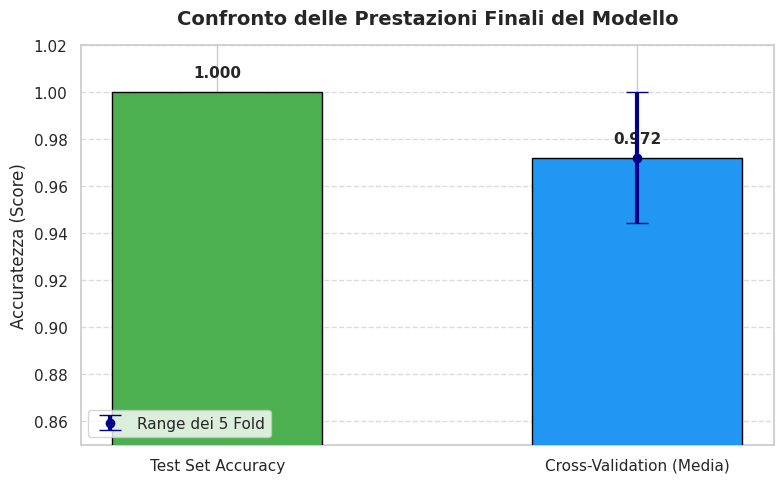

In [ ]:
# Dati dal tuo progetto
folf_min = scores.min()
fold_max = scores.max()
cv_mean = scores.mean()
test_accuracy = 1.00

# Configurazione del grafico
plt.figure(figsize=(8, 5))
labels = ['Test Set Accuracy', 'Cross-Validation (Media)']
values = [test_accuracy, cv_mean]
colors = ['#4CAF50', '#2196F3'] # Verde per il test, Blu per la CV

# Disegno delle barre
bars = plt.bar(labels, values, color=colors, width=0.5, edgecolor='black', zorder=3)

# Aggiungiamo la barra di errore (baffo) sulla Cross-Validation per mostrare il range (min/max)
plt.errorbar('Cross-Validation (Media)', cv_mean,
             yerr=[[cv_mean - folf_min], [fold_max - cv_mean]],
             fmt='o', color='darkblue', elinewidth=3, capsize=8, label='Range dei 5 Fold', zorder=4)

# Personalizzazione grafica
plt.ylim(0.85, 1.02) # Limita l'asse Y per vedere meglio i dettagli
plt.ylabel('Accuratezza (Score)', fontsize=12)
plt.title('Confronto delle Prestazioni Finali del Modello', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Aggiunta dei valori numerici sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Mostra il grafico finale a schermo
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


Il grafico a barre sintetizza visivamente la validazione finale del classificatore:

* **Test Set Accuracy (1.000):** La barra verde indica il punto di partenza della nostra analisi, in cui il modello ha ottenuto il massimo punteggio sullo split di test statico.
* **Cross-Validation Media (0.972):** La barra azzurra mostra il reale valore atteso delle prestazioni del modello quando viene testato in modo dinamico su tutto il dataset.
* **Range dei 5 Fold (Baffo Blu):** L'indicatore di errore evidenzia l'oscillazione dei punteggi nei 5 blocchi di validazione. Il fold meno performante si attesta comunque su un ottimo ~0.944, mentre il migliore raggiunge l'1.000.

**Conclusione Economica e Tecnica:** La ridotta ampiezza del range di errore (baffo) dimostra che il modello non soffre di alta varianza (overfitting distruttivo). La discrepanza tra il 100% del test statico e il 97.2% della validazione incrociata è fisiologica e conferma che il modello è robusto, affidabile e pronto per l'uso.


Per poter analizzare nel dettaglio gli errori commessi dal modello senza influenzare la valutazione con dati già visti in addestramento, si utilizza la funzione **cross_val_predict**.

Questo approccio genera una **predizione "pulita" per ogni singolo campione del dataset**: l'elemento viene valutato esclusivamente quando si trova nel blocco di test, garantendo che il modello non abbia mai visto quel dato durante la fase di fitting. Il vettore di output ottenuto (**y_cv**) conterrà le **etichette predette associate a ciascun vino** e sarà la base fondamentale per calcolare la successiva **matrice di confusione**.

In [ ]:
# Genera predizioni tramite Cross-Validation a 5 fold sul miglior modello stimato
# Ogni predizione è generata da un modello che non ha visto il dato in addestramento
y_cv = cross_val_predict(
    grid.best_estimator_,  # La pipeline ottimizzata con i parametri ideali
    X,                     # La matrice delle caratteristiche standardizzate
    y,                     # Il vettore reale delle classi target dei vini
    cv=5                   # Numero di partizioni per la convalida incrociata
)

Per ottenere una panoramica dettagliata e approfondita sulle performance del classificatore, viene generato il **report di classificazione complessivo** tramite la funzione **classification_report**.

**Questo strumento confronta i valori reali del dataset (y) con le predizioni ottenute in cross-validation (y_cv)**, calcolando per ogni singola classe di vino tre metriche fondamentali: la **Precision** (accuratezza delle predizioni positive), la **Recall** (capacità di individuare tutti i campioni positivi) e l'**F1-Score** (la media armonica tra le due). L'analisi di questo report permette di verificare se il modello mostra **comportamenti sbilanciati** o difficoltà specifiche nel distinguere una classe dalle altre.

In [ ]:
# Genera e stampa a schermo il report completo delle metriche di classificazione
# Confronta le etichette reali (y) con quelle predette in cross-validation (y_cv)
print(classification_report(y, y_cv))

              precision    recall  f1-score   support

           1       1.00      0.98      0.99        59
           2       0.99      0.94      0.96        71
           3       0.92      1.00      0.96        48

    accuracy                           0.97       178
   macro avg       0.97      0.98      0.97       178
weighted avg       0.97      0.97      0.97       178



Il report evidenzia prestazioni eccezionali e un comportamento estremamente bilanciato del modello su tutte e tre le classi di vino:
- **Classe 1 (Precisione Perfetta)**: Raggiunge una **Precision del 100% (1.00)**. Significa che ogni volta che il modello assegna un vino alla classe 1, non commette mai un errore di falso positivo. La **Recall del 98% (0.98)** indica che quasi tutti i 59 campioni disponibili sono stati intercettati correttamente
-  **Classe 2 (Ottimo Bilanciamento)**: Mostra una **Precision del 99% e una Recall del 94%**. Pur essendo la classe con più campioni (**support = 71**), il classificatore mantiene un **F1-Score del 96%**, dimostrando una grandissima solidità nel differenziarla dalle altre
- **Classe 3 (Sensibilità Massima)**: Ottiene una **Recall del 100% (1.00)**. Questo implica che il modello ha identificato correttamente **tutti i 48 campioni** appartenenti a questa classe, senza mancarne nemmeno uno (zero falsi negativi). La precisione leggermente inferiore (**92%**) indica solo che qualche raro campione delle altre classi è stato erroneamente scambiato per la classe 3
- **Medie Globali Eccellenti**: L'**Accuracy generale del 97%** trova perfetta corrispondenza nelle metriche di sintesi (**macro avg e weighted avg**), che si attestano stabilmente tra il **97% e il 98%**. Questo conferma l'assenza di squilibri o penalizzazioni dovute alla differente numerosità delle classi (**support**).

Per completare lo studio delle performance e localizzare con precisione millimetrica i singoli errori di classificazione, viene generata la **matrice di confusione**.

Il codice calcola la matrice incrociando i dati reali con quelli predetti e sfrutta la libreria seaborn per visualizzarla sotto forma di **mappa di calore (heatmap)**. Questo grafico permette di visualizzare immediatamente sulle diagonali i **corretti posizionamenti del modello** (veri positivi) e, nelle celle esterne, la natura esatta degli scambi di classe commessi dall'algoritmo durante i test.

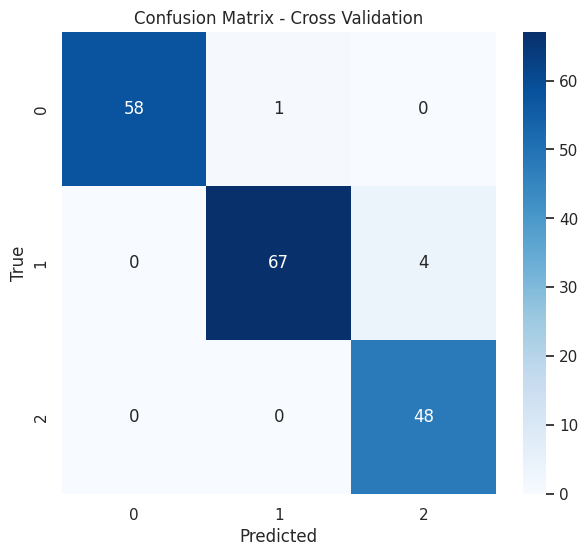

In [ ]:
# Calcola la matrice di confusione confrontando i target reali e quelli predetti in CV
cm_cv = confusion_matrix(y, y_cv)

# Inizializza la figura grafica definendo le dimensioni del grafico (larghezza, altezza)
plt.figure(figsize=(7, 6))

# Genera la mappa di calore per visualizzare la matrice di confusione
sns.heatmap(
    cm_cv,          # La matrice numerica dei dati calcolata precedentemente
    annot=True,     # Mostra all'interno di ogni cella il rispettivo valore numerico
    fmt="d",        # Formatta i numeri come interi decimali (evita la notazione scientifica)
    cmap="Blues"    # Applica una scala cromatica basata sulle sfumature di blu
)

# Imposta il titolo principale del grafico della matrice di confusione
plt.title("Confusion Matrix - Cross Validation")

# Assegna l'etichetta descrittiva all'asse delle ascisse (valori predetti dal modello)
plt.xlabel("Predicted")

# Assegna l'etichetta descrittiva all'asse delle ordinate (valori reali nel dataset)
plt.ylabel("True")

# Rendering finale e visualizzazione a schermo del grafico completo
plt.show()

**Commento alla Matrice di Confusione**

Diversamente dalla confusion matrix calcolata sul solo test set,
questa matrice riassume le predizioni ottenute durante la
cross validation su tutti i campioni del dataset **testo in grassetto**.

**Fornisce quindi una valutazione più robusta** delle capacità
di generalizzazione del modello.

La matrice di confusione conferma visivamente l'estrema precisione del modello e permette di localizzare esattamente i **soli 5 errori di classificazione** commessi su un totale di 178 campioni:
- **Diagonale Principale (Predizioni Corrette)**: La forte concentrazione del colore blu sulla diagonale evidenzia che la stragrande maggioranza dei vini è stata classificata correttamente. Il modello ha intercettato con successo **58 campioni della Classe 0, 67 della Classe 1 e tutti i 48 della Classe 2**
- **Analisi degli Errori (Fuori dalla Diagonale)**:
1) **Classe 0 (Vino 1)**: Viene commesso **un solo errore**. Un campione appartenente alla Classe 0 è stato erroneamente classificato come Classe 1
2) **Classe 1 (Vino 2)**: Rappresenta la classe con il maggior numero di sviste, pari a **4 errori**. Questi 4 campioni sono stati scambiati e assegnati alla Classe 2
3) **Classe 2 (Vino 3)**: Mostra una pulizia totale nella propria riga. Il **valore 0 nelle altre celle conferma la Recall del 100%** già vista nel report: nessun vino di tipo 2 è stato mancato dall'algoritmo
- **Spiegazione della Precisione della Classe 2**: La cella in basso a destra mostra le 48 predizioni corrette della Classe 2. Tuttavia, la colonna "2" accoglie anche i 4 errori provenienti dalla Classe 1. Questo spiega matematicamente perché la Precision della Classe 2 si era attestata al 92% nel report precedente (48 predizioni corrette su 52 totali dirette verso quella colonna).

Il grafico dimostra in modo inequivocabile che **le classi sono altamente separabili** nello spazio delle caratteristiche geometriche e che il modello SVM incontra una lievissima e fisiologica sovrapposizione solo nel distinguere i campioni tra la seconda e la terza tipologia di vino.

*(Nota: Scikit-learn indicizza internamente le classi partendo da 0, quindi le classi 0, 1 e 2 corrispondono rispettivamente alle classi 1, 2 e 3 del classification report precedente)*.

La **Permutation Importance** è una tecnica avanzata per calcolare l'**importanza delle caratteristiche** (feature importance) basata sul reale impatto che ogni variabile ha sulle performance del modello. Questo metodo supera i limiti dei modelli non lineari come le SVM, misurando quanto diminuisce l'accuratezza del classificatore quando i valori di una singola colonna vengono **mescolati casualmente** (permutati). Se il punteggio cala drasticamente, significa che il modello si affida fortemente a quella variabile per prendere le sue decisioni. La visualizzazione tramite un **grafico a barre orizzontali** permette di identificare immediatamente quali sono i **fattori chimici determinanti** per la classificazione dei vini, ordinandoli dal meno importante al più influente.

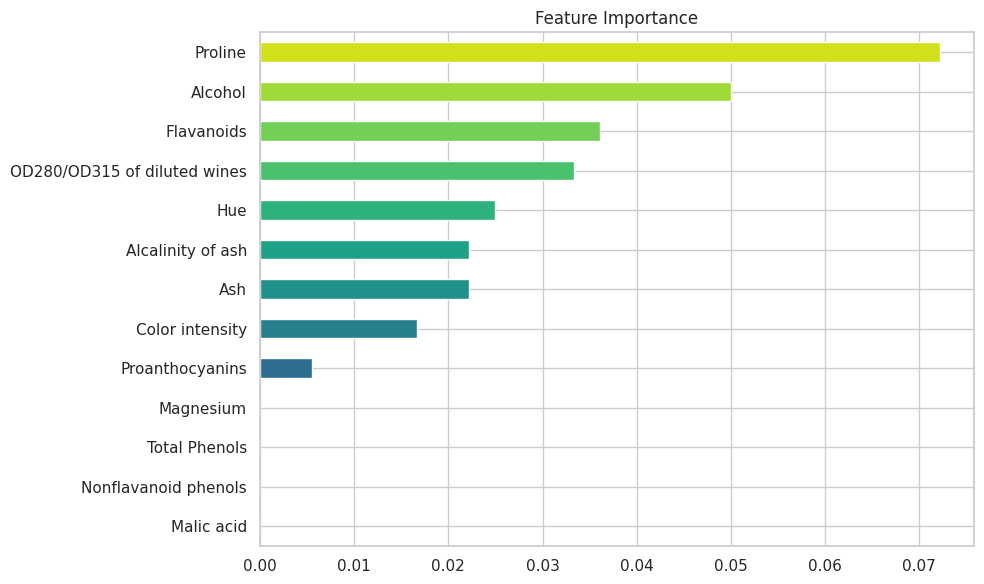

In [ ]:
# Calcola l'importanza delle feature sul dataset di test per valutare l'impatto reale
result = permutation_importance(
    grid.best_estimator_,  # Il modello ottimizzato da valutare
    X_test,                # La matrice delle caratteristiche di test
    y_test,                # Il vettore target di test
    n_repeats=10,          # Numero di volte in cui mescolare ogni feature per fare la media
    random_state=42        # Garantisce la riproducibilità degli stessi risultati casuali
)

# Associa i valori medi di importanza ottenuti ai rispettivi nomi delle colonne di X
importance = pd.Series(
    result.importances_mean,
    index=X.columns
)

# Ordina i valori in modo crescente prima di generare il grafico
importance_sorted = importance.sort_values()

# Genera una lista di colori diversi per ogni colonna usando la palette 'viridis'
# (Puoi cambiare 'viridis' con 'plasma', 'coolwarm' o 'rocket' se preferisci altre tonalità)
colori = sns.color_palette("viridis", len(importance_sorted))

# Imposta le dimensioni della figura
plt.figure(figsize=(10,6))

# Crea il grafico a barre orizzontali assegnando la lista dei colori diversi
importance_sorted.plot(
    kind='barh',
    color=colori
)

# Configura il titolo principale del grafico descrittivo
plt.title("Feature Importance")

# Ottimizza il layout per evitare che i nomi delle variabili vengano tagliati
plt.tight_layout()

# Mostra il grafico finale a schermo pulendo l'output
plt.show()


Il grafico evidenzia quali caratteristiche chimiche guidano le decisioni del modello sul Test Set, quantificando la perdita di accuratezza quando i valori di una feature vengono mescolati:

* **Driver Principali:** **Proline** (Prolina) e **Alcohol** (Alcol) sono le variabili più critiche in assoluto. La prolina, in particolare, mostra l'impatto maggiore, seguita a breve distanza dall'alcol e dai **Flavanoids** (Flavonoidi).
* **Feature Secondarie:** Caratteristiche come *OD280/OD315*, *Hue* e *Alcalinity of ash* forniscono un contributo di rifinitura importante per la classificazione (tra lo 0.02 e o 0.035).
* **Feature Irrilevanti:** Variabili come *Malic acid*, *Nonflavanoid phenols*, *Total Phenols* e *Magnesium* hanno un'importanza pari a zero su questo specifico split di test. Il modello non ne risente minimamente se vengono alterate.

**Verifica del 100% di Accuratezza:**
L'importanza non è concentrata su un'unica feature dominante (che avrebbe fatto sospettare un leak), ma è distribuita in modo bilanciato su 4-5 caratteristiche biochimiche chiave del vino. Questo dimostra che il modello ha appreso pattern multi-variabile complessi e reali, confermando l'alta qualità del classificatore su questo specifico dominio.


# **💡 Conclusioni**

In questo progetto è stata sviluppata una **pipeline completa di Machine Learning** per la **classificazione dei vini** a partire dalle loro caratteristiche chimiche.

Dopo una fase iniziale di analisi esplorativa e preparazione dei dati, è stato addestrato un classificatore **Support Vector Machine (SVM)**, ottimizzato tramite **GridSearchCV**.

La ricerca degli iperparametri ha individuato come configurazione migliore un **kernel RBF con valori ottimali di C e gamma**, ottenendo un'**elevata accuratezza sia durante la validazione incrociata sia sul test set**.

La **Cross Validation** rappresenta la misura più affidabile della **capacità di generalizzazione** del modello, mentre il **test set** conferma l'elevata qualità delle predizioni su dati non utilizzati durante l'addestramento.

Infine, l'analisi tramite **Permutation Importance** ha evidenziato le caratteristiche chimiche maggiormente influenti nella classificazione, rendendo il modello non solo accurato ma anche **interpretabile**.

Questo approccio dimostra come le tecniche di **Machine Learning** possano supportare efficacemente il **controllo qualità** e la certificazione nel **settore vitivinicolo**.